# Modèle de diffusion (DDPM)

Un DDPM codé à la main, d'après Ho et al. (2020). D'abord sur California, où le prix est généré avec les autres colonnes. Puis sur MAGIC, où le modèle génère les variables sachant la classe.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

### Préparation des données California
Chaque colonne est ramenée à une loi normale avec un `QuantileTransformer`. Problème : les valeurs au plafond (`HouseAge` = 52, prix = 5) sont toutes égales, donc elles tombent toutes sur le même quantile extrême de la normale. Ça fait un pic qui gêne le modèle de diffusion.

On ajoute donc un bruit minuscule avant la transformation. Les valeurs deviennent toutes distinctes, leurs rangs s'étalent sur la plage de quantiles qu'elles occupent, et la sortie redevient une gaussienne continue.

In [2]:
cal_train = pd.read_csv("data/processed/california_train.csv")
display(cal_train.head())
cols = cal_train.columns

rng = np.random.default_rng(0)
bruit_depart = 1e-6 * cal_train.std().to_numpy() * rng.uniform(-1, 1, cal_train.shape)   # départage les plafonds
qt = QuantileTransformer(output_distribution="normal", n_quantiles=1000, subsample=None, random_state=0)
x0 = torch.from_numpy(qt.fit_transform(cal_train + bruit_depart)).float()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,1.6900,18.0,4.423529,1.145882,994.0,2.338824,34.14,-116.32,0.542
1,3.3889,32.0,4.338731,1.153497,2725.0,1.764896,33.97,-118.37,2.857
2,6.0074,16.0,6.862705,1.114754,2003.0,4.104508,37.58,-122.08,2.365
3,2.5900,45.0,5.471111,1.131111,1587.0,3.526667,37.74,-122.40,2.118
4,2.2639,15.0,3.845528,0.971545,550.0,2.235772,36.82,-119.72,0.525


### Processus avant : le bruitage
Calendrier linéaire du papier : β va de 1e-4 à 0,02 sur T = 1000 pas. Pas besoin de bruiter pas à pas, on peut aller directement au pas t :

x_t = √ᾱ_t · x_0 + √(1 − ᾱ_t) · ε, avec ᾱ_t le produit des (1 − β) jusqu'à t.

Plus t est grand, plus il reste de bruit et moins de signal. La figure montre la carte de Californie qui disparaît.

In [3]:
def get_linear_schedule(t = 1000, beta_start= 1e-4, beta_end = 0.02):
    """Calendrier linéaire du papier DDPM. Renvoie aussi les alpha et leur produit cumulé."""
    betas = torch.linspace(beta_start, beta_end, t, dtype=torch.float32)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    return betas, alphas, alphas_cumprod


def x_t_forward(t, x0):
    eps = torch.randn_like(x0)
    ab = alphas_cumprod[t].view(-1, 1)          # (batch, 1) ou (1, 1) si t scalaire
    x_t = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * eps
    return x_t, eps

In [4]:
betas,alphas,alphas_cumprod=get_linear_schedule(t = 1000, beta_start= 1e-4, beta_end = 0.02)
print(betas.shape)

x100,eps = x_t_forward(100, x0)
print((x100 - x0).std())

torch.Size([1000])
tensor(0.3286)


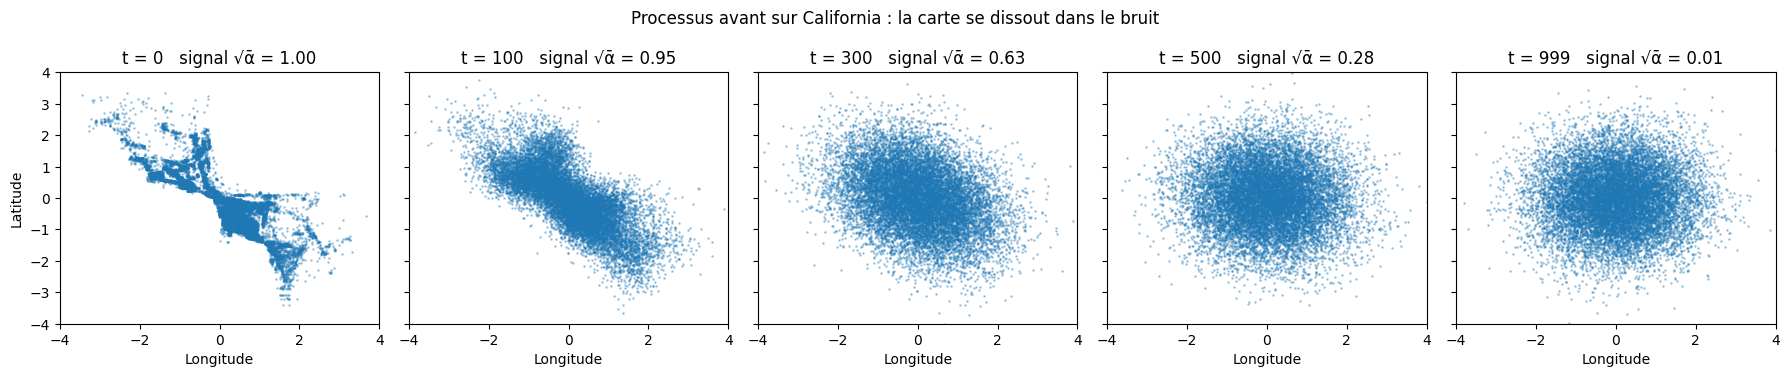

In [5]:
lat, lon = cols.get_loc("Latitude"), cols.get_loc("Longitude")
pas = [0, 100, 300, 500, 999]

fig, axes = plt.subplots(1, len(pas), figsize=(18, 3.8), sharex=True, sharey=True)
for ax, t in zip(axes, pas):
    xt, _ = x_t_forward(t, x0)
    ax.scatter(xt[:, lon], xt[:, lat], s=1, alpha=0.3)
    ax.set_title(f"t = {t}   signal √ᾱ = {alphas_cumprod[t].sqrt():.2f}")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.suptitle("Processus avant sur California : la carte se dissout dans le bruit")
fig.tight_layout()
fig.savefig("figures/ddpm_bruitage_california.png", dpi=150, bbox_inches="tight")

### Architecture du débruiteur
Un MLP de 3 couches de 256 qui prédit le bruit ε contenu dans x_t. Il faut aussi lui donner le pas t, et j'ai testé deux façons :

- version 1 : t/T directement, un seul nombre entre 0 et 1 ;
- version 2 : l'embedding sinusoïdal du papier. t devient 32 sinus et cosinus de fréquences différentes, un peu comme des aiguilles qui tournent à des vitesses différentes. Les rapides distinguent deux pas voisins, les lentes situent t sur l'ensemble des 1000 pas.

In [6]:
T = 1000  

class Debruiteur(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1,256),nn.SiLU(), # +1 pour t
            nn.Linear(256,256),nn.SiLU(),
            nn.Linear(256,256),nn.SiLU(),
            nn.Linear(256,d)
        )

    def forward(self, x_t, t):
        t_norm = (t.float() / T).unsqueeze(1)          # (batch,) -> (batch, 1), entre 0 et 1
        h = torch.cat([x_t, t_norm], dim=1)            # (batch, d + 1)
        return self.net(h)

In [7]:

# Version 2 : embedding sinusoïdal du temps
def embedding_temps(t, dim=32):
    i = torch.arange(dim // 2)                                    # une « aiguille » par i
    freqs = 1.0 / 10000 ** (2 * i / dim)                          # vitesses de 1 à ~1/10 000
    angles = t.float().unsqueeze(1) * freqs.unsqueeze(0)          # (batch, dim/2)
    return torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)   # (batch, dim)


class DebruiteurSinus(nn.Module):
    def __init__(self, d, dim_temps=32, largeur=256):
        super().__init__()
        self.dim_temps = dim_temps
        self.mlp_temps = nn.Sequential(                # le réseau apprend quoi faire des aiguilles
            nn.Linear(dim_temps, dim_temps), nn.SiLU(),
            nn.Linear(dim_temps, dim_temps),
        )
        self.reseau = nn.Sequential(
            nn.Linear(d + dim_temps, largeur), nn.SiLU(),   # entrée : x_t + embedding du temps
            nn.Linear(largeur, largeur), nn.SiLU(),
            nn.Linear(largeur, largeur), nn.SiLU(),
            nn.Linear(largeur, d),
        )

    def forward(self, x_t, t):
        e = self.mlp_temps(embedding_temps(t, self.dim_temps))   # (batch, dim_temps)
        h = torch.cat([x_t, e], dim=1)                            # (batch, d + dim_temps)
        return self.reseau(h)                                     # (batch, d)

### Entraînement du débruiteur
À chaque batch, on tire un t au hasard pour chaque ligne, on bruite, et le réseau doit retrouver le bruit ajouté (erreur quadratique, la perte simplifiée du papier). Un checkpoint est sauvegardé toutes les 20 epochs.

In [8]:
# Jeu de validation, transformé avec le qt du train (transform seulement, pas de fit)
cal_val = pd.read_csv("data/processed/california_val.csv")
x0_val = torch.from_numpy(qt.transform(cal_val)).float()

# On fixe une fois pour toutes le t et le bruit de chaque ligne de validation,
# pour que la perte de validation soit comparable d'une epoch à l'autre
g = torch.Generator().manual_seed(123)
t_val = torch.randint(0, T, (len(x0_val),), generator=g)
eps_val = torch.randn(x0_val.shape, generator=g)
ab_val = alphas_cumprod[t_val].view(-1, 1)
x_t_val = torch.sqrt(ab_val) * x0_val + torch.sqrt(1 - ab_val) * eps_val

os.makedirs("checkpoints", exist_ok=True)

In [9]:
torch.manual_seed(0)

d = x0.shape[1]
model = Debruiteur(d)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loader = DataLoader(TensorDataset(x0), batch_size=256, shuffle=True)

n_epochs = 200
for epoch in range(n_epochs):
    model.train()
    total = 0.0
    for (xb,) in loader:
        t = torch.randint(0, T, (xb.shape[0],))   # un t par exemple du batch
        x_t, eps = x_t_forward(t, xb)             # bruitage : x_t = √ᾱ·x0 + √(1-ᾱ)·ε
        eps_pred = model(x_t, t)                  # le modèle voit x_t, pas xb
        loss = F.mse_loss(eps_pred, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.shape[0]

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        model.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(model(x_t_val, t_val), eps_val).item()
        torch.save(model.state_dict(), f"checkpoints/ddpm_naif_ep{epoch}.pt")
        print(f"epoch {epoch:3d}  train {total / len(loader.dataset):.4f}  val {val_loss:.4f}")

epoch   0  train 0.4566  val 0.2993
epoch  20  train 0.2451  val 0.2376
epoch  40  train 0.2467  val 0.2363
epoch  60  train 0.2387  val 0.2357
epoch  80  train 0.2424  val 0.2332
epoch 100  train 0.2379  val 0.2328
epoch 120  train 0.2425  val 0.2310
epoch 140  train 0.2363  val 0.2309
epoch 160  train 0.2369  val 0.2307
epoch 180  train 0.2392  val 0.2302
epoch 199  train 0.2370  val 0.2295


### Entraînement avec l'embedding sinusoïdal
Même boucle, même nombre d'epochs et même graine : seule la façon de donner t au réseau change.

In [10]:
torch.manual_seed(0)

model_sinus = DebruiteurSinus(d)
optimizer_sinus = torch.optim.Adam(model_sinus.parameters(), lr=1e-3)

for epoch in range(n_epochs):
    model_sinus.train()
    total = 0.0
    for (xb,) in loader:
        t = torch.randint(0, T, (xb.shape[0],))
        x_t, eps = x_t_forward(t, xb)
        eps_pred = model_sinus(x_t, t)
        loss = F.mse_loss(eps_pred, eps)

        optimizer_sinus.zero_grad()
        loss.backward()
        optimizer_sinus.step()
        total += loss.item() * xb.shape[0]

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        model_sinus.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(model_sinus(x_t_val, t_val), eps_val).item()
        torch.save(model_sinus.state_dict(), f"checkpoints/ddpm_sinus_ep{epoch}.pt")
        print(f"epoch {epoch:3d}  train {total / len(loader.dataset):.4f}  val {val_loss:.4f}")

epoch   0  train 0.5023  val 0.2919
epoch  20  train 0.2428  val 0.2385
epoch  40  train 0.2494  val 0.2358
epoch  60  train 0.2419  val 0.2352
epoch  80  train 0.2435  val 0.2341
epoch 100  train 0.2442  val 0.2332
epoch 120  train 0.2491  val 0.2328
epoch 140  train 0.2414  val 0.2320
epoch 160  train 0.2377  val 0.2316
epoch 180  train 0.2377  val 0.2309
epoch 199  train 0.2400  val 0.2300


### Génération
On part d'un bruit pur et on remonte les 1000 pas jusqu'à x_0. À chaque pas, on retire le bruit prédit par le réseau, puis on rajoute un peu de bruit frais (sauf au dernier pas). C'est l'algorithme 2 du papier.

In [11]:
def generate(n,d,model):
    with torch.no_grad():
        x_t = torch.randn(n,d)
        for t in range(T - 1, -1, -1):  # de 999 à 0
            t_batch  = torch.full((n,), t, dtype=torch.long)
            eps_pred = model(x_t, t_batch )
            if t > 0 :
                z = torch.randn(n,d)
            else :
                z = 0
            x_t = 1 / torch.sqrt(alphas[t]) * (x_t - (1-alphas[t]) / torch.sqrt(1-alphas_cumprod[t]) * eps_pred) + torch.sqrt(betas[t]) * z
    return x_t

In [12]:
torch.manual_seed(0)
x_gen = generate(len(cal_train), d, model)
synth = pd.DataFrame(qt.inverse_transform(x_gen.numpy()), columns=cols)
synth["HouseAge"] = synth["HouseAge"].round()

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


In [13]:
# pareil avec la version sinusoïdale
torch.manual_seed(0)
x_gen_sinus = generate(len(cal_train), d, model_sinus)
synth_sinus = pd.DataFrame(qt.inverse_transform(pd.DataFrame(x_gen_sinus.numpy(), columns=cols)), columns=cols)
synth_sinus["HouseAge"] = synth_sinus["HouseAge"].round()

### Premières vérifications
La carte des logements, en réel et pour les deux versions.

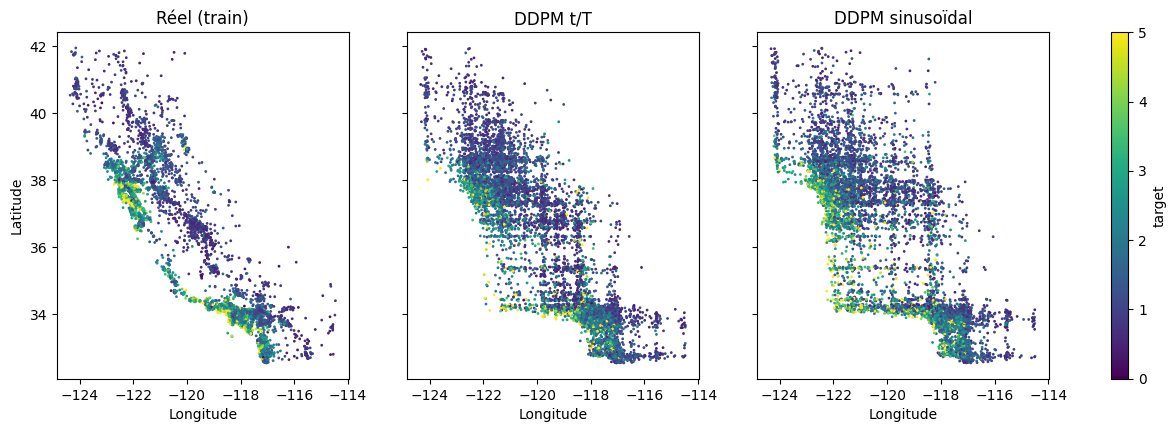

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
for ax, (nom, df) in zip(axes, [("Réel (train)", cal_train), ("DDPM t/T", synth), ("DDPM sinusoïdal", synth_sinus)]):
    sc = ax.scatter(df["Longitude"], df["Latitude"], c=df["target"], s=1, cmap="viridis", vmin=0, vmax=5)
    ax.set_title(nom)
    ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes, label="target")
fig.savefig("figures/ddpm_carte_reel_vs_synth.png", dpi=150, bbox_inches="tight")

Part des lignes au plafond, puis moyenne, écart-type, min et max de chaque colonne.

In [15]:
for nom, df in [("réel", cal_train), ("t/T", synth), ("sinus", synth_sinus)]:
    print(f"{nom:6s} HouseAge=52 : {(df['HouseAge'] == 52).mean():.3f}   target au plafond : {(df['target'] > 5.0).mean():.3f}")

pd.concat({"réel": cal_train.describe().T[["mean", "std", "min", "max"]],
           "t/T": synth.describe().T[["mean", "std", "min", "max"]]}, axis=1).round(2)

réel   HouseAge=52 : 0.062   target au plafond : 0.046
t/T    HouseAge=52 : 0.050   target au plafond : 0.035
sinus  HouseAge=52 : 0.051   target au plafond : 0.051


réel                                 t/T                   \
               mean      std     min       max     mean      std     min   
MedInc         3.88     1.90    0.50     15.00     3.58     1.82    0.50   
HouseAge      28.69    12.59    1.00     52.00    28.54    12.24    1.00   
AveRooms       5.45     2.69    0.89    141.91     5.17     2.64    0.89   
AveBedrms      1.10     0.52    0.50     34.07     1.09     0.50    0.50   
Population  1420.36  1154.93    3.00  35682.00  1538.24  1542.43    3.00   
AveOccup       3.04     6.87    0.75    599.71     3.23    10.46    0.76   
Latitude      35.63     2.13   32.54     41.95    35.59     2.15   32.54   
Longitude   -119.57     2.00 -124.35   -114.47  -119.45     1.98 -124.33   
target         2.07     1.15    0.15      5.00     1.86     1.06    0.15   

                      
                 max  
MedInc         15.00  
HouseAge       52.00  
AveRooms      141.74  
AveBedrms      33.84  
Population  35650.15  
AveOccup      585.67  
Latitude       41.94  
Longitude    -114.48  
target          5.00

In [16]:
print("écart max de corrélation de Spearman, t/T   :", (cal_train.corr("spearman") - synth.corr("spearman")).abs().max().max().round(3))
print("écart max de corrélation de Spearman, sinus :", (cal_train.corr("spearman") - synth_sinus.corr("spearman")).abs().max().max().round(3))

écart max de corrélation de Spearman, t/T   : 0.094
écart max de corrélation de Spearman, sinus : 0.073


In [17]:
os.makedirs("data/synthetic", exist_ok=True)
synth.to_csv("data/synthetic/california_ddpm_naif.csv", index=False)
synth_sinus.to_csv("data/synthetic/california_ddpm_sinus.csv", index=False)

### Quelques chiffres de plus

In [18]:
from scipy.stats import wasserstein_distance
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

# Un point est « hors carte » s'il est à plus de 0,2° du vrai logement le plus proche (océan, Nevada…)
nn_geo = NearestNeighbors(n_neighbors=1).fit(cal_train[["Longitude", "Latitude"]])

# La validation réelle sert de référence : c'est ce que donnerait un générateur parfait
for nom, df in [("val réel", cal_val), ("t/T", synth), ("sinus", synth_sinus)]:
    w = np.mean([wasserstein_distance(cal_train[c], df[c]) / cal_train[c].std() for c in cols])
    ecart_corr = (cal_train.corr("spearman") - df.corr("spearman")).abs().max().max()
    hors_carte = (nn_geo.kneighbors(df[["Longitude", "Latitude"]])[0][:, 0] > 0.2).mean()
    print(f"{nom:8s}  Wasserstein {w:.3f}   écart corr max {ecart_corr:.3f}   hors carte {hors_carte:.3f}   moyenne target {df['target'].mean():.2f}")

# Aperçu de l'utilité, sur la validation (le test est gardé pour le notebook 05)
for nom, df in [("t/T", synth), ("sinus", synth_sinus)]:
    gbm = HistGradientBoostingRegressor(random_state=0, early_stopping=False).fit(df.drop(columns="target"), df["target"])
    r2 = r2_score(cal_val["target"], gbm.predict(cal_val.drop(columns="target")))
    print(f"{nom:6s}  R² sur la val d'un GBM entraîné sur le synthétique : {r2:.3f}   (entraîné sur le train réel : 0.833)")

val réel  Wasserstein 0.024   écart corr max 0.038   hors carte 0.005   moyenne target 2.06
t/T       Wasserstein 0.081   écart corr max 0.094   hors carte 0.040   moyenne target 1.86
sinus     Wasserstein 0.046   écart corr max 0.073   hors carte 0.073   moyenne target 2.10
t/T     R² sur la val d'un GBM entraîné sur le synthétique : 0.750   (entraîné sur le train réel : 0.833)
sinus   R² sur la val d'un GBM entraîné sur le synthétique : 0.747   (entraîné sur le train réel : 0.833)


### Bilan de la génération (California, modèles après 200 epochs)

| | Val réelle (référence) | DDPM t/T | DDPM sinusoïdal |
|---|---|---|---|
| Wasserstein moyen des marginales (/σ) | 0,024 | 0,081 | 0,046 |
| Écart max des corrélations de Spearman | 0,038 | 0,094 | 0,073 |
| Points hors carte (> 0,2° d'un vrai logement) | 0,5 % | 4,0 % | 7,3 % |
| Part de `HouseAge = 52` (réel : 6,2 %) | | 5,0 % | 5,1 % |
| Part de la cible au plafond (réel : 4,6 %) | | 3,5 % | 5,1 % |
| Moyenne de la cible (réel : 2,07) | 2,06 | 1,86 | 2,10 |
| R² sur la val d'un GBM entraîné dessus (réel : 0,833) | | 0,750 | 0,747 |

Les deux versions génèrent des données crédibles, sans être parfaites.

Ce qui marche : la carte retrouve les deux pôles, Los Angeles et la baie de San Francisco, ainsi que le lien entre prix et position (les logements chers sont bien sur la côte). Les plafonds de `HouseAge` et de la cible sont reconstruits, à peu près dans les bonnes proportions.

Ce qui manque : la côte est floue. Entre 4 et 7 % des points tombent loin de tout vrai logement, dans l'océan ou au Nevada, contre 0,5 % pour la validation réelle. On voit aussi des lignes horizontales et verticales sur la carte : chaque marginale est respectée, puisque la transformation par quantiles y veille, mais la dépendance fine entre longitude et latitude n'est apprise qu'en partie. Côté utilité, un modèle entraîné sur ces données perd environ 0,08 de R² (0,75 contre 0,833). C'est moins bien que d'entraîner sur seulement 25 % du train réel (0,809).

t/T ou sinusoïdal : pas de gagnant net. La version sinusoïdale reproduit mieux les marginales, alors que la version t/T sous-estime les prix (1,86 contre 2,07 en moyenne). En revanche, elle place presque deux fois plus de points hors de la carte. Les corrélations et l'utilité sont équivalentes. C'est un premier écho de la question du projet : ici, les mesures de ressemblance ne s'accordent pas entre elles, et leurs différences ne changent pas l'utilité.

À garder en tête : un seul tirage par modèle, et une utilité mesurée sur la validation.

## MAGIC : génération conditionnée sur la classe

Ici on ne génère que les 10 variables. La classe (0 = gamma, 1 = hadron) est tirée dans les proportions du train puis donnée au réseau en entrée, à côté de x_t et de t. Mêmes réglages que pour California : t/T, 3 couches de 256, 200 epochs, batch 256, lr 1e-3.

In [19]:
magic_train = pd.read_csv("data/processed/magic_train.csv")
magic_val = pd.read_csv("data/processed/magic_val.csv")
cols_m = magic_train.columns.drop("target")

# même préparation que California, mais seulement sur les variables (pas sur la classe)
rng = np.random.default_rng(0)
bruit_m = 1e-6 * magic_train[cols_m].std().to_numpy() * rng.uniform(-1, 1, magic_train[cols_m].shape)
qt_m = QuantileTransformer(output_distribution="normal", n_quantiles=1000, subsample=None, random_state=0)
x0_m = torch.from_numpy(qt_m.fit_transform(magic_train[cols_m] + bruit_m)).float()
y_m = torch.tensor(magic_train["target"].values).float()

print(x0_m.shape, "part de hadrons :", y_m.mean().item())

torch.Size([13233, 10]) part de hadrons : 0.3476913869380951


In [20]:
class DebruiteurCond(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 2, 256), nn.SiLU(),  # x_t + t + classe
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, d)
        )

    def forward(self, x_t, t, y):
        t_norm = (t.float() / T).unsqueeze(1)
        h = torch.cat([x_t, t_norm, y.unsqueeze(1)], dim=1)
        return self.net(h)

In [21]:
# validation : bruitage fixé une fois pour toutes, comme pour California
x0_val_m = torch.from_numpy(qt_m.transform(magic_val[cols_m])).float()
y_val_m = torch.tensor(magic_val["target"].values).float()

g = torch.Generator().manual_seed(123)
t_val_m = torch.randint(0, T, (len(x0_val_m),), generator=g)
eps_val_m = torch.randn(x0_val_m.shape, generator=g)
ab = alphas_cumprod[t_val_m].view(-1, 1)
x_t_val_m = torch.sqrt(ab) * x0_val_m + torch.sqrt(1 - ab) * eps_val_m

In [22]:
torch.manual_seed(0)

d_m = x0_m.shape[1]
model_m = DebruiteurCond(d_m)
optimizer_m = torch.optim.Adam(model_m.parameters(), lr=1e-3)
loader_m = DataLoader(TensorDataset(x0_m, y_m), batch_size=256, shuffle=True)

n_epochs = 200
for epoch in range(n_epochs):
    model_m.train()
    total = 0.0
    for xb, yb in loader_m:
        t = torch.randint(0, T, (xb.shape[0],))
        x_t, eps = x_t_forward(t, xb)
        loss = F.mse_loss(model_m(x_t, t, yb), eps)

        optimizer_m.zero_grad()
        loss.backward()
        optimizer_m.step()
        total += loss.item() * xb.shape[0]

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        model_m.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(model_m(x_t_val_m, t_val_m, y_val_m), eps_val_m).item()
        torch.save(model_m.state_dict(), f"checkpoints/ddpm_magic_ep{epoch}.pt")
        print(f"epoch {epoch:3d}  train {total / len(loader_m.dataset):.4f}  val {val_loss:.4f}")

epoch   0  train 0.4617  val 0.2776
epoch  20  train 0.2088  val 0.2065
epoch  40  train 0.2094  val 0.2018
epoch  60  train 0.2011  val 0.1988
epoch  80  train 0.1947  val 0.1964
epoch 100  train 0.2012  val 0.1969
epoch 120  train 0.1981  val 0.1959
epoch 140  train 0.1985  val 0.1941
epoch 160  train 0.1975  val 0.1953
epoch 180  train 0.1977  val 0.1944
epoch 199  train 0.1972  val 0.1936


In [23]:
def generate_cond(n, d, model, y):
    with torch.no_grad():
        x_t = torch.randn(n, d)
        for t in range(T - 1, -1, -1):
            t_batch = torch.full((n,), t, dtype=torch.long)
            eps_pred = model(x_t, t_batch, y)
            if t > 0:
                z = torch.randn(n, d)
            else:
                z = 0
            x_t = 1 / torch.sqrt(alphas[t]) * (x_t - (1 - alphas[t]) / torch.sqrt(1 - alphas_cumprod[t]) * eps_pred) + torch.sqrt(betas[t]) * z
    return x_t


torch.manual_seed(0)
n_m = len(magic_train)
y_gen = y_m[torch.randint(0, n_m, (n_m,))]   # classes tirées au hasard dans celles du train
x_gen_m = generate_cond(n_m, d_m, model_m, y_gen)

synth_m = pd.DataFrame(qt_m.inverse_transform(pd.DataFrame(x_gen_m.numpy(), columns=cols_m)), columns=cols_m)
synth_m["target"] = y_gen.int().numpy()

print("part de hadrons : réel", round(magic_train["target"].mean(), 3), "| synthétique", round(synth_m["target"].mean(), 3))
synth_m.to_csv("data/synthetic/magic_ddpm.csv", index=False)

part de hadrons : réel 0.348 | synthétique 0.343


### Vérifications MAGIC

Pas de carte ici, alors on regarde les distributions par classe de trois variables, en réel (trait plein) et en synthétique (pointillés). `fAlpha` est la variable qui sépare le mieux gamma et hadron : si le conditionnement marche, ses deux courbes synthétiques doivent être aussi différentes que les réelles.

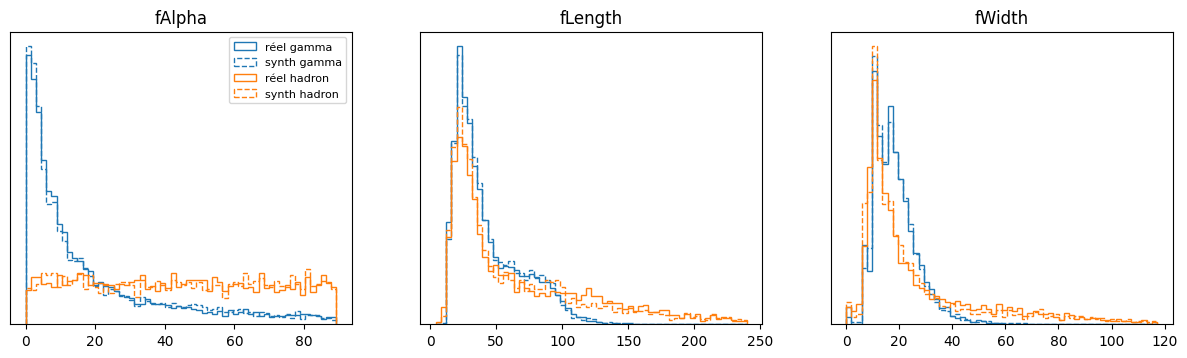

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, c in zip(axes, ["fAlpha", "fLength", "fWidth"]):
    bornes = (magic_train[c].min(), magic_train[c].quantile(0.995))
    for cl, nom, couleur in [(0, "gamma", "C0"), (1, "hadron", "C1")]:
        ax.hist(magic_train.loc[magic_train["target"] == cl, c], bins=60, range=bornes, density=True,
                histtype="step", color=couleur, label=f"réel {nom}")
        ax.hist(synth_m.loc[synth_m["target"] == cl, c], bins=60, range=bornes, density=True,
                histtype="step", color=couleur, linestyle="--", label=f"synth {nom}")
    ax.set_title(c)
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.savefig("figures/ddpm_magic_reel_vs_synth.png", dpi=150, bbox_inches="tight")

In [25]:
from scipy.stats import wasserstein_distance
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

for nom, df in [("val réel", magic_val), ("synthétique", synth_m)]:
    w = np.mean([wasserstein_distance(magic_train[c], df[c]) / magic_train[c].std() for c in cols_m])
    ecart_corr = (magic_train.corr("spearman") - df.corr("spearman")).abs().max().max()
    print(f"{nom:12s} Wasserstein {w:.3f}   écart corr max {ecart_corr:.3f}")

# aperçu de l'utilité sur la val
gbm = HistGradientBoostingClassifier(random_state=0, early_stopping=False).fit(synth_m[cols_m], synth_m["target"])
auc = roc_auc_score(magic_val["target"], gbm.predict_proba(magic_val[cols_m])[:, 1])
print(f"AUC sur la val d'un GBM entraîné sur le synthétique : {auc:.3f}   (entraîné sur le train réel : 0.937)")

val réel     Wasserstein 0.028   écart corr max 0.046
synthétique  Wasserstein 0.038   écart corr max 0.072
AUC sur la val d'un GBM entraîné sur le synthétique : 0.927   (entraîné sur le train réel : 0.937)
